In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [36]:
c=2.998*10**8 #in m/s

#in natural units:
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
f=14 #coupling strength

#in eV
w_minus = 60*10**-3
w_plus = 20*10**-3
m_Si_nucleus = 2.616e10
proton_mass= 938.272e6

dm_density = 0.3e9 #eV/cm^3, plus minus 0.1
target_density = 1.307e33 #eV/cm^3 from silicon density of 2329.6 kg/m3

#in 1/eV
a_Si = 2*np.pi/(2.28*1000) #Silicon lattice constant
a0 = 2.68e-4 #Bohr radius

# Structure Factor

The equation for the Structure Factor is as follows:
\begin{aligned}
    S(q,\omega) &= \sum_{\ell,\ell'} |f|^2 C_{\ell, \ell'} \\
    &= 2|f|^2 (C_{\ell=\ell'}+C_{\ell \neq \ell'})
\end{aligned}
The diagonal term is $$ C_{\boldsymbol{\ell}d} = \frac{1}{V} e^{-2W_d(\boldsymbol{q})} \sum_{n=0} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_+(n-j)\omega_--\omega)$$ and the off-diagonal is $$C_{\boldsymbol{\ell '}\boldsymbol{\ell} d}=\frac{1}{V}e^{i\boldsymbol{q}\cdot(\boldsymbol{l}-\boldsymbol{\ell'})} e^{-2W_d(\boldsymbol{q})} \sum_{n=0}^{\omega/\omega_+} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi(-1)^{n-j}}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_+(n-j)\omega_--\omega)$$

The function $W_d(q)$ is the Debye-Waller factor: $W_d(q)=\frac{q^2}{8m_d}(\frac{1}{\omega_1}+\frac{1}{\omega_2})$. When you integrate with $\omega$, the delta function gets removed, leaving a sum based on n and j for set values of $\omega_{n,j}$



In [37]:
"""
The Debye-Waller function for a two-site lattice
@params 
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
"""
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [38]:
"""
The diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
"""
def diagonal_C_true(q, m, w1,w2, n, j, V=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [39]:
"""
The off-diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
"""
def offDiagonal_C_true(q, m, w1,w2, n, j, V=a_Si, a=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*a)
    return c

In [40]:
"""
Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n(q, m, w1,w2, n, V, a, A=f):
    return sum([2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)
                        +offDiagonal_C_true(q, m, w1,w2, n, j, V, a)) for j in range(n+1)] )

In [41]:
"""
Diagonal Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    A: coupling strength
"""
def StructureFactor_diag(q, m, w1,w2, n, V, A):
    return sum([2*A**2* diagonal_C_true(q, m, w1,w2, n, j, V) for j in range(n+1)] )

In [42]:
#Calculate the structure factor integrated wrt omega for first 4 phonon numbers
q_range = 10**np.linspace(-1, np.log10(300), 3000) #keV
S_int_w = [[StructureFactor_n(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, a_Si, 1) for q in q_range] 
           for n in range(1,5)] #structure factor
S_int_diag= [[StructureFactor_diag(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, 1) for q in q_range] 
            for n in range(1,5)] #diagonal portion for reference

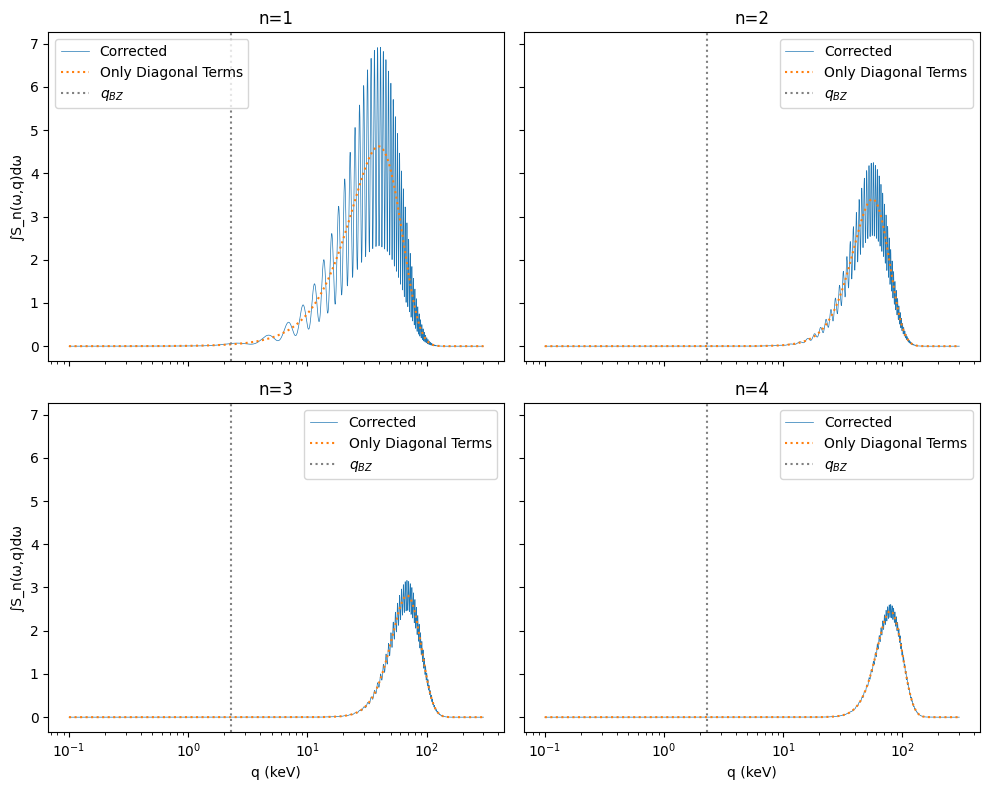

In [43]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(10, 8))
for n in range(4):
    axs[int(n/2), n%2].plot(q_range, S_int_w[n], linewidth=0.5, label = "Corrected")
    axs[int(n/2), n%2].plot(q_range, S_int_diag[n], linewidth=1.5, linestyle = ":", label="Only Diagonal Terms")
    axs[int((n)/2), n%2].set_xscale('log')
    axs[int((n)/2), n%2].set_title("n="+str(n+1))
    axs[int((n)/2), n%2].axvline(2.28, color="gray", linestyle=":", label=r"$q_{BZ}$")
    axs[int((n)/2), n%2].legend()
for ax in axs.flat:
    ax.set(xlabel='q (keV)', ylabel='∫S_n(ω,q)dω')
for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()
plt.show()

We can also make a color graph that shows the structure factor as a function of both energy and momentum transfer

In [44]:
"""
Find the possible combinations of n and j that give energies lower or equal to the maximum energy transfer
@params:
    omega: energy transfer from dark matter to crystal
    w1, w2: energy levels of the element
@returns:
    a list of paired principle phonon numbers and phonon modes
"""
def get_possible_n_j(omega, w1 = w_plus,w2=w_minus): 
    maxN = int(omega/w1)
    pairs = [(n, j) for n in range(1,maxN + 1) for j in range(n + 1)]
    pairs_array = np.array(pairs)
    n_values = pairs_array[:, 0]
    j_values = pairs_array[:, 1]
    condition = (j_values * w1 + (n_values - j_values) * w2) <= omega
    filtered_pairs = pairs_array[condition]
    return filtered_pairs

"""
Find all energies from the n,j pair
@params:
    n_j_pairs: a list of paired principle phonon numbers and phonon modes
    w1, w2: energy levels of the element
@ returns:
    List of all possible energies
"""
def get_possible_omega(n_j_pairs, w1 = w_plus,w2=w_minus):
    n_values = n_j_pairs[:, 0]
    j_values = n_j_pairs[:, 1]
    return j_values * w1 + (n_values - j_values) * w2

"""
Removes degenerate energies
@params:
    omega_list: list of energies
    s_list: list of structure factors
@returns:
    List of unique energies
    Corresponding list of structure factors
"""
def remove_degeneracy(omega_list, s_list):
    unique_omega = np.unique(omega_list)
    unique_s = []
    for val in unique_omega:
        indices = np.where(omega_list == val)[0]
        unique_s.append(np.sum(s_list[indices], axis=0))
    return unique_omega, np.array(unique_s)

In [45]:
#We get all the pairs of n,j and corresponding energies up to the maximum energy, which we set to be 300 meV
maxOmega = 0.300 #eV
n_j_list = get_possible_n_j(maxOmega)
possible_omega_list = get_possible_omega(n_j_list)

qbz = 2*np.pi / a_Si #First Brillouin zone of the Silicon lattice

#Create the momentum range for the graph
log_q_list = np.linspace(0, np.log10(400), 10000)
q_list = 10**log_q_list # keV


#Create the diagonal and corrected structure factors for each energy and momentum
s_list = []
s_diag_list = []
for n_j_pairs in n_j_list: #iterate for each n,j pair
    s_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1])+
                  2*f**2 * offDiagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
    s_diag_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
#remove the degeneracies in the lists
clean_omega_list, clean_s_list = remove_degeneracy(possible_omega_list, np.array(s_list))
clean_omega_list, clean_s_diag_list = remove_degeneracy(possible_omega_list, np.array(s_diag_list))

#Create the omega range for the plot.  There are 4000 points
omega_list = np.linspace(0, maxOmega, 4000) # eV

#Make a matrix of structure factors, where the horizontal axis is momentum transfer and the vertical is energy
s_list_plot = np.zeros((len(omega_list), len(log_q_list)))
s_diag_list_plot = np.zeros((len(omega_list), len(log_q_list)))
for i, w in enumerate(clean_omega_list):
    ind = np.where((omega_list > w - 0.0006) & (omega_list < w + 0.0006))[0] #round the calculated energies to the set energy points
    s_list_plot[ind, :] = clean_s_list[i]
    s_diag_list_plot[ind, :] = clean_s_diag_list[i]


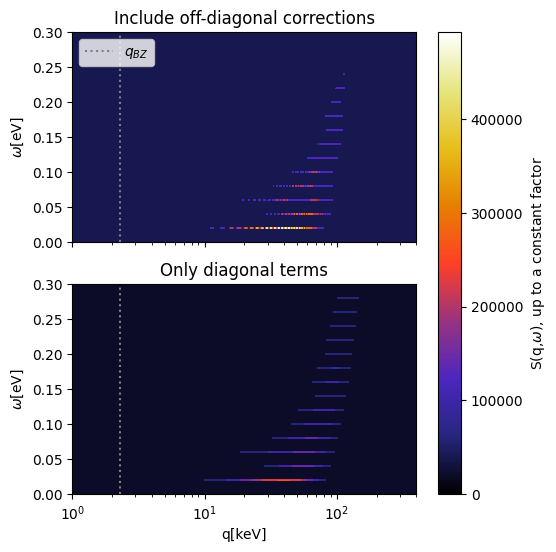

In [46]:
#Graphing the structure factor colorplot
X, Y = np.meshgrid(q_list,omega_list)
fig, axes = plt.subplots(nrows=2, figsize=(4,6),sharey=True,sharex=True)
cmap = matplotlib.colormaps.get_cmap('CMRmap')
normalizer = Normalize(0, np.max(s_list_plot))
im = cm.ScalarMappable(norm=normalizer, cmap='CMRmap')

axes[0].contourf(X, Y, s_list_plot,cmap='CMRmap',norm=normalizer)
axes[0].axvline(qbz/1000, linestyle=':', color='gray',label=r'$q_{BZ}$') #Brillouin zone in keV
axes[0].set_xscale('log')
axes[0].set_title('Include off-diagonal corrections')
axes[0].set_ylabel('$\omega$[eV]')
axes[0].legend(loc='upper left')


axes[1].contourf(X, Y, s_diag_list_plot,cmap='CMRmap', norm=normalizer)
axes[1].axvline(2*np.pi/(a_Si*1000), linestyle=':', color='gray')
axes[1].set_xscale('log')
axes[1].set_title('Only diagonal terms')
axes[1].set_xlabel('q[keV]')
axes[1].set_ylabel('$\omega$[eV]')

fig.subplots_adjust(right=1.2, wspace=0)
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label(r'S(q,$\omega$), up to a constant factor', )

plt.show()

# Differential Momentum Spectrum
We will now find the derivative of the scattering rate with respect to q.  The equation for the scattering rate is $$ R_\chi = \frac{\rho_\chi}{\rho_T m_\chi} \int \frac{dq \, q}{(2\pi)^2} \, \cdot \frac{\pi \sigma}{\mu_\chi^2} \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)$$ 

This makes the derivative with respect to q: $$\frac{\partial R}{\partial q} = \frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)=\frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \sum_n \sum_{j=0}^n \eta(v_{min}(q,\omega_{n,j})) \cdot S_{n,j}(q)$$

In [47]:
"""
This gives the two-body reduced mass equation
@params:
    m1, m2: masses of the two bodies
@returns: Effective mass of the two bodies
"""
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

First, we code the inverse mean function $\eta(v_{min})$

In [48]:
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))

"""
Helper function 1 and 2 for finding the output of the inverse mean function.
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const
def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const


"""
Returns the inverse mean value for any given v_min.  
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

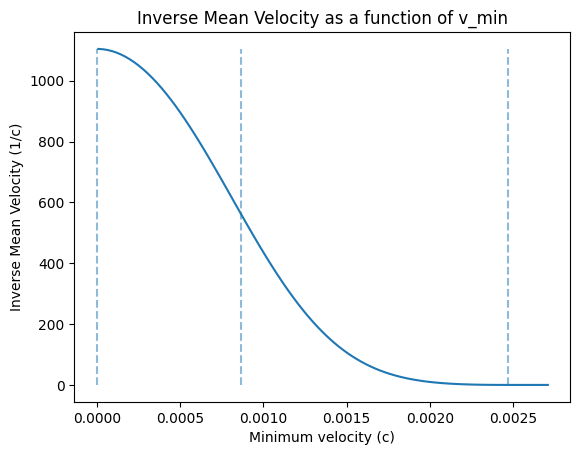

In [49]:
#Graphing the inverse mean as a function of the minimum velocity

vmin_range = np.linspace(0.01*v_E, v_esc+v_E*1.3, 100)
imf_mass = 50
imf_vmin = [inverseMeanFunction(v, imf_mass) for v in vmin_range]

plt.plot(vmin_range, imf_vmin)
plt.vlines([0, v_esc-v_E, v_esc+v_E], 0,max(imf_vmin), linestyles="dashed", alpha=0.5)
plt.title("Inverse Mean Velocity as a function of v_min")
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("Minimum velocity (c)")
plt.show()

In [50]:
"""
Find the minumum speed of dark matter
@params: 
    q: momentum transfer
    m_chi: mass of a dark matter particle
    w: energy transfer
@returns: minimum velocity of dark matter to hit crystal
"""
def v_min(q,m_chi, w): 
    return w/q+q/(2*m_chi)

Once we have the mean velocity equation, we can then find the derivative of the scattering rate with respect to q and integrate to find the scattering rate for one type of phonon

In [51]:
"""
This gives the derivative of the scattering rate with respect to the momentum transfer
@params:
    q: momentum transfer
    m_chi: mass of dark matter
    n: principle phonon number
    j: phonon mode number
    sigma: cross section
    A: coupling strength
    V: volume of the crystal
    a: lattice constant of the crystal
@returns:
    dR/dq
    offDiagonal_C_true(q, m, w1,w2, n, j, V=a_Si, a=a_Si)
"""
def R_deriv_q_onePhonon(q, m_chi, n, j,sigma=1, A=f, V=a_Si, a=a_Si): 
    sFactor = 2*A**2*(diagonal_C_true(q, m_Si_nucleus, w_plus, w_minus, n, j, V)
                      +offDiagonal_C_true(q, m_Si_nucleus, w_plus, w_minus, n, j, V, a))
    reducMass = reducedMass(m_chi, proton_mass)
    front_terms = dm_density*sigma/(4*np.pi*target_density*m_chi* reducMass**2)
    w_curr=n*w_minus+j*(w_plus-w_minus)
    return front_terms*q*inverseMeanFunction(v_min(q,m_chi, w_curr), m_chi)*sFactor*2.998e10 *3.15576e7 *1000

In [52]:
q_range = np.linspace(3,5.5,200)
q_range = 10**q_range


deriv = [[sum([R_deriv_q_onePhonon(q,40e6, n,j, sigma=1e-42) for j in range(n+1)]) 
          for q in q_range] for n in range(1,11)]

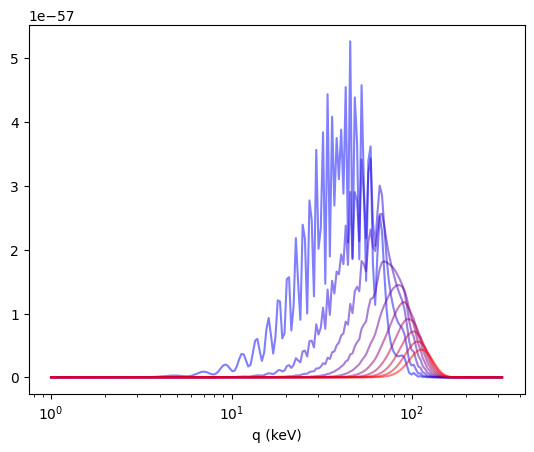

In [53]:
for i in range(10):
    plt.plot(q_range/1000, deriv[i], color=(i/9, 0,1-i/9), alpha=0.5)
#plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
#plt.ylim([1e-8,10])
plt.show()